In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

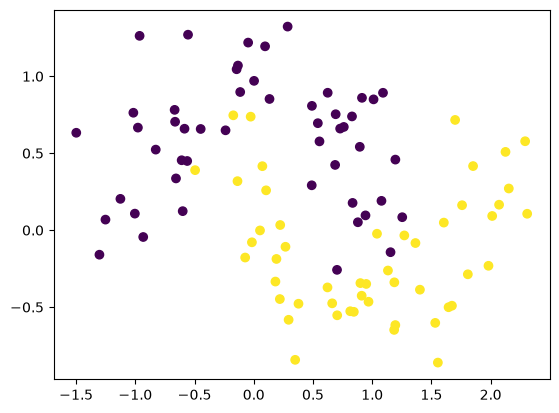

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### 12_Zero_weight_initializaion_with_sigmoid

In [18]:
model=Sequential([
    Dense(units=128 , activation='sigmoid', input_dim=2),
    Dense(units=1 , activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.get_weights()

[array([[ 0.1295671 , -0.16971517,  0.15886246,  0.13369946,  0.1058255 ,
          0.0960242 , -0.19331452, -0.1992125 ,  0.17039625, -0.17151235,
          0.02475585,  0.09740157,  0.13901569,  0.03142661,  0.18568854,
         -0.15938333,  0.1984063 , -0.04558079, -0.1886046 ,  0.18394311,
          0.05663581, -0.08005539, -0.04463823, -0.11736073, -0.1172317 ,
         -0.06369877, -0.17211184,  0.13364379,  0.05804028, -0.11587881,
          0.04765348, -0.1191265 ,  0.01021998, -0.17919876, -0.14475173,
          0.13217805, -0.05477682, -0.14766178, -0.15359725,  0.02058917,
          0.12936457, -0.10681017,  0.06646062,  0.08980899,  0.13778861,
         -0.06889586,  0.1026556 , -0.03224865,  0.14103322, -0.12694229,
          0.06918971,  0.01284897, -0.20518611, -0.1352961 ,  0.15856604,
         -0.00370821, -0.20142677, -0.03931841, -0.00642581,  0.09436987,
         -0.17824948,  0.15826313,  0.14554785,  0.03070712, -0.01224719,
          0.08073543, -0.11696894, -0.

In [20]:
initial_weights = model.get_weights()

In [21]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [22]:
model.set_weights(initial_weights)

In [23]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [24]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4125 - loss: 0.7364 - val_accuracy: 0.3500 - val_loss: 0.7345
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 0.6854 - val_accuracy: 0.6500 - val_loss: 0.6735
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4625 - loss: 0.7038 - val_accuracy: 0.6500 - val_loss: 0.6929
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4125 - loss: 0.6989 - val_accuracy: 0.3500 - val_loss: 0.7392
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5375 - loss: 0.6952 - val_accuracy: 0.3500 - val_loss: 0.7445
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5375 - loss: 0.6884 - val_accuracy: 0.3500 - val_loss: 0.7155
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5375 - loss: 0.6871 - val_accuracy: 0.3500 - val_loss: 0.7015
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5375 - loss: 0.6907 - val_accuracy: 0.3500 - val_loss: 0.7111

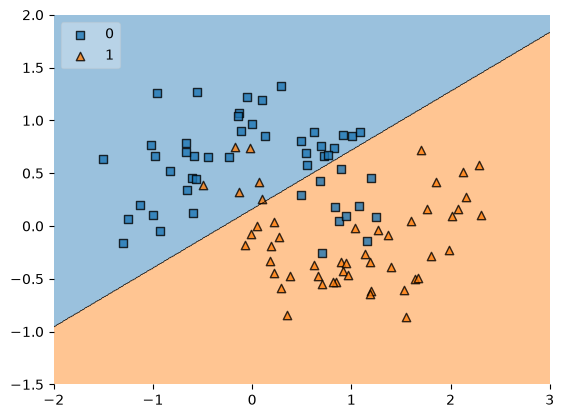

In [25]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

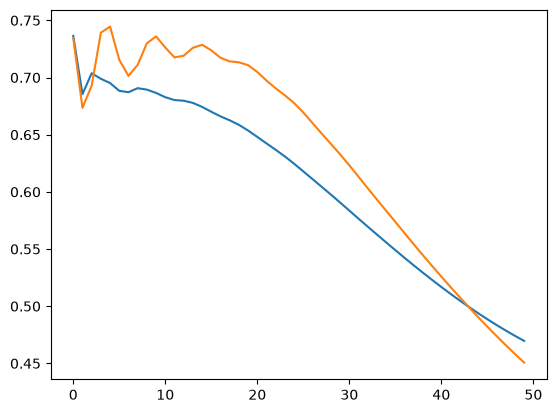

In [26]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])